<a href="https://colab.research.google.com/github/ericnmt/htd-benchmarking/blob/main/notebooks/T1600-HT-ML-Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AES-T1600 HT Detection ML Pipeline
Eric Johnson
Sem-supervised Hardware Trojan detection on the AES TRojan power side-channel dataset. Set the Trojan variant and plaintext mode in the **Configuration** cell, then run all cells top to bottom.

In [2]:
# Install numpy, matplotlib, scikit-learn, pyod, pandas
%pip install numpy matplotlib scikit-learn combo pyod pandas torch
!rm -rf sample_data
!mkdir -p src/content/data/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyod as pyod
import sklearn
import torch
import os

Note: you may need to restart the kernel to use updated packages.


### Configuration
Change `TROJAN` and `PLAINTEXT` to run a different variance. Every path, filename, and plot title below is derived from these two values. Outputs are stored per variance and per plaintext mode.

In [3]:
# DEFINE TROJAN VARIANT
TROJAN = "1600"

PLAINTEXT = "2" # '2' = fixed plaintext, '1' = varied plaintext
BENCHMARK = f"AES-T{TROJAN}"

DATA = f"data/{BENCHMARK}/npy_arrays/"

# RUN LOCALLY AT THE PROJECT ROOT
# Input: converted numpy arrays (output of 00_convert.py)
OUT = f"data/{BENCHMARK}/"
DATA_PREP_FIGS = f"{OUT}data-prep-figs/"
FIGS = f"{OUT}roc_auc_plots/"
ENCODINGS = f"{OUT}npy_encodings/"
DFS = f"{OUT}roc_auc_dataframes/"

for folder in (DATA_PREP_FIGS, FIGS, ENCODINGS, DFS):
  os.makedirs(folder, exist_ok=True)

print(f"Running {BENCHMARK}, plaintext {PLAINTEXT}")

Running AES-T1600, plaintext 2


### Verify Numpy conversions

Convert the raw data into numpy arrays before running this cell by using the `00_convert.py` script, and place them in the folder set by DATA

In [4]:
# Output the name of the numpy array and its corresponding properties

files = os.listdir(DATA)

if not files:
  print("No files found, verify that the files have been uploaded to the proper path.")

else:
  for file in files:
    X = np.load(DATA + file)
    print(f'{file:12s} shape={X.shape}, dtype={X.dtype}, nan={np.isnan(X).sum()}')

AES-T1600+TrojanDisabled_2.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T1600+TrojanDisabled_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T1600+TrojanTriggered_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T1600+TrojanTriggered_2.npy shape=(10000, 2500), dtype=float32, nan=0


### Load Data
Load the selected plaintext mode's arrays: Trojan disabled (normal) and Trojan triggered (anomalous).

In [5]:
# Normal: Trojan disabled, Anomalous: Trojan triggered
disabled = np.load(f"{DATA}{BENCHMARK}+TrojanDisabled_{PLAINTEXT}.npy")
triggered = np.load(f"{DATA}{BENCHMARK}+TrojanTriggered_{PLAINTEXT}.npy")

print(disabled, triggered)

[[45. 44. 44. ... 49. 47. 45.]
 [45. 44. 44. ... 50. 47. 47.]
 [45. 45. 44. ... 50. 47. 46.]
 ...
 [46. 45. 44. ... 51. 50. 47.]
 [45. 44. 44. ... 49. 48. 46.]
 [45. 44. 44. ... 49. 48. 46.]] [[46. 45. 44. ... 49. 47. 46.]
 [46. 43. 43. ... 49. 47. 43.]
 [47. 46. 44. ... 52. 47. 47.]
 ...
 [45. 44. 43. ... 48. 47. 46.]
 [45. 45. 44. ... 49. 47. 47.]
 [45. 45. 43. ... 49. 47. 45.]]


### Define The Data Splits

In [6]:
# 50/50 split on trian/test (normal only data)
train_normal = disabled[:5000]
test_normal = disabled[5000:]
test_anom = triggered[:]

print(train_normal.shape, test_normal.shape, test_anom.shape)

(5000, 2500) (5000, 2500) (10000, 2500)


### Fit Scaler

In [7]:
from sklearn.preprocessing import StandardScaler

# Compute the mean/std per one of 2500 columns, from train_normal
scaler = StandardScaler().fit(train_normal)

train_s = scaler.transform(train_normal)
test_norm_s = scaler.transform(test_normal)
test_anom_s = scaler.transform(test_anom)

### Initialize Autoencoder
The framework of choice is PyTorch because of its compatibility with PyOD. We define the autoencoder as a class, with a constructor and a function (forward) to return the latent space layer, $z$, and the reconstructed layer.

In [8]:
import torch.nn as nn

class AutoEncoder(nn.Module):
  """
  AutoEncoder class constructor and forward function

  Constructor: Creates the input, hidden, and latent space layers.
  Forward: Returns the reconstructed layer, and the latent space representation
  """
  def __init__(self):
    super().__init__()
    # Encoder
    self.encoder = nn.Sequential(
        # Input features compressed as: 2500 -> 512 -> 128 -> 32
        nn.Linear(2500, 512), nn.ReLU(),
        nn.Linear(512, 128), nn.ReLU(),
        nn.Linear(128, 32))  # Latent space, z
    # Decoder
    self.decoder = nn.Sequential(
        # Output features reconstructed as: 32 -> 128 -> 512 -> 2500
        nn.Linear(32, 128), nn.ReLU(),
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 2500)) # Reconstructed layer

  def forward(self, x):
    z = self.encoder(x)
    # Return the reconstructed layer, and the latent space representation
    return self.decoder(z), z

### Train AutoEncoder
This step consists of training the autoencoder and basic analysis of the training results. The autoencoder was trained with the following:
- T4 GPU for GPU required models
- Apple M5 for other models
- Adam Optimizer (LR = 0.001)
- 20 total epochs. Note that this choice was derived from an earlier run which used a validation set, 20 was the most optimal epoch.
- MSE loss

In [9]:
from torch.utils.data import TensorDataset, DataLoader

N_EPOCHS = 20
SEED = 42

device = "cpu"

# Initialize the model object
torch.manual_seed(SEED)
np.random.seed(SEED)
model = AutoEncoder().to(device)

# Define the learning optimizer
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Define loss function
loss_fn = nn.MSELoss()

# Initialize tensors
train_t = torch.tensor(train_s, dtype=torch.float32)

# Load the dataset into "loader"
loader = DataLoader(TensorDataset(train_t), batch_size = 64, shuffle=True)

train_losses = []

# Train loop
for epoch in range(N_EPOCHS):
  model.train()
  epoch_loss = 0
  for (batch,) in loader:
    batch = batch.to(device)
    opt.zero_grad()
    recon, _ = model(batch)
    loss = loss_fn(recon, batch)
    loss.backward()
    opt.step()
    epoch_loss += loss.item() * len(batch)
  train_losses.append(epoch_loss / len(train_t))
  print(f"epoch {epoch}: train_loss={train_losses[-1]:.4f}")

print("done")

epoch 0: train_loss=0.8510
epoch 1: train_loss=0.8072
epoch 2: train_loss=0.7805
epoch 3: train_loss=0.7650
epoch 4: train_loss=0.7537
epoch 5: train_loss=0.7439
epoch 6: train_loss=0.7349
epoch 7: train_loss=0.7267
epoch 8: train_loss=0.7179
epoch 9: train_loss=0.7097
epoch 10: train_loss=0.7009
epoch 11: train_loss=0.6927
epoch 12: train_loss=0.6853
epoch 13: train_loss=0.6777
epoch 14: train_loss=0.6722
epoch 15: train_loss=0.6671
epoch 16: train_loss=0.6619
epoch 17: train_loss=0.6571
epoch 18: train_loss=0.6523
epoch 19: train_loss=0.6486
done


<function matplotlib.pyplot.show(close=None, block=None)>

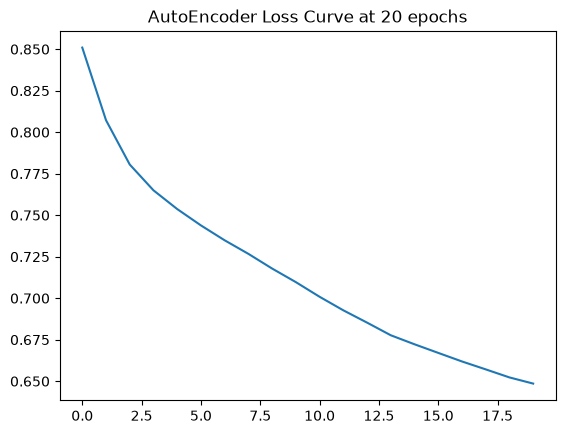

In [10]:
# Loss curve plot analysis
plt.plot(train_losses, label="train")
plt.legend
plt.title(f"AutoEncoder Loss Curve at {N_EPOCHS} epochs")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

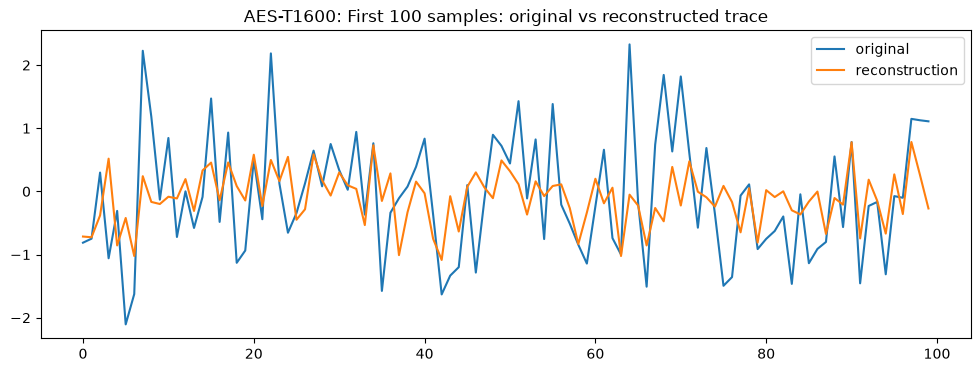

In [11]:
# Analyze reconstructed data
model.eval()

with torch.no_grad():
  recon_0, _ = model(train_t[:1].to(device))

plot_index_range = 100

plt.figure(figsize=[12,4])
plt.plot(train_s[0][:plot_index_range], label="original")
plt.plot(recon_0.cpu().numpy()[0][:plot_index_range], label="reconstruction")
plt.legend()
plt.title(f"{BENCHMARK}: First {plot_index_range} samples: original vs reconstructed trace")
plt.show

If the original and reconstructed plot look similar, we cna conclude that the AutoEncoder learned, generalized, and reconstructed the features of the original data sufficiently.

### Encode Data Splits
At this step, encode all the splits using pre-trained autoencoder

In [12]:
model.eval()

with torch.no_grad():
  # Encode training split latent space
  Z_train = model.encoder(train_t.to(device)).cpu().numpy()
  np.save(f"{ENCODINGS}Z_train.npy", Z_train)

  # Encode test normal split latent space
  Z_test_norm = model.encoder(torch.tensor(test_norm_s, dtype=torch.float32).to(device)).cpu().numpy()
  np.save(f"{ENCODINGS}Z_test_norm.npy", Z_test_norm)

  # Encode test anomalous split latent space
  Z_test_anom = model.encoder(torch.tensor(test_anom_s, dtype=torch.float32).to(device)).cpu().numpy()
  np.save(f"{ENCODINGS}Z_test_anom.npy", Z_test_anom)

  torch.save(model.state_dict(), "ae_seed0.pt")

print(Z_train.shape)

(5000, 32)


In [13]:
# Standardize the latent dimensions, fit on the training latents only
# Scaled copies get an _s suffix
z_scaler = StandardScaler().fit(Z_train)

Z_train_s = z_scaler.transform(Z_train)
Z_test_norm_s = z_scaler.transform(Z_test_norm)
Z_test_anom_s = z_scaler.transform(Z_test_anom)

### Evaluation
`compute_metrics` turns two score arrays (test normal, test anomalous) into threshold-free metrics (ROC-AUC, PR-AUC) and saves the curves.

`evaluate_detector` builds a fresh PyOD detector, fits it on the scaled training latents, scores both test sets, and passes the scores to `compute_metrics`. The `invert=True` boolean negates the scores for detectors whose native output was found to run backward on this data.

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay

def compute_metrics(name, scores_normal, scores_anom, plot=True):
  scores = np.concatenate([scores_normal, scores_anom])
  labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anom))])

  result = {
      "model": name,
      "roc_auc": roc_auc_score(labels, scores),
      "pr_auc": average_precision_score(labels, scores)
  }

  if plot:
    RocCurveDisplay.from_predictions(labels, scores, name=name)
    plt.title(f"{name} ROC Curve {BENCHMARK}")
    plt.savefig(f"{FIGS}{name}_roc_curve", dpi=240, bbox_inches='tight')
    plt.show()
  return result

def evaluate_detector(name, make_detector, Z_train, Z_test_norm, Z_test_anom, invert=False, plot=True):
  clf = make_detector()
  clf.fit(Z_train)

  scores_norm = clf.decision_function(Z_test_norm)
  scores_anom = clf.decision_function(Z_test_anom)

  if invert:
    scores_norm *= -1
    scores_anom *= -1
  result = compute_metrics(name, scores_norm, scores_anom, plot=plot)
  result["inverted"] = invert
  return result

### AutoEncoder Reconstruction Check
Here, we check if the autoencoder learned anything useful, using each trace's reconstruction error as its anomaly score. Ideal case is 1.0. The reconstruction errors are resued by MAD below.


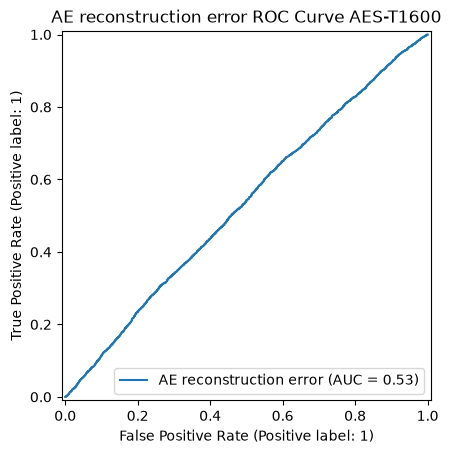

{'model': 'AE reconstruction error', 'roc_auc': 0.53068512, 'pr_auc': 0.6833080556589998}


In [15]:
def recon_error(x_s):
  model.eval()
  with torch.no_grad():
    x_t = torch.tensor(x_s, dtype=torch.float32).to(device)
    recon, _ = model(x_t)
  return ((recon.cpu().numpy() - x_s) ** 2).mean(axis=1)

err_train = recon_error(train_s)
err_test_norm = recon_error(test_norm_s)
err_test_anom = recon_error(test_anom_s)

recon_result = compute_metrics("AE reconstruction error", err_test_norm, err_test_anom)
print(recon_result)

### Detector Benchmarks
#### Probabilistic Models

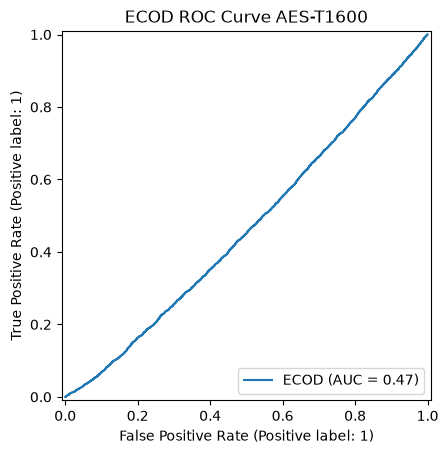

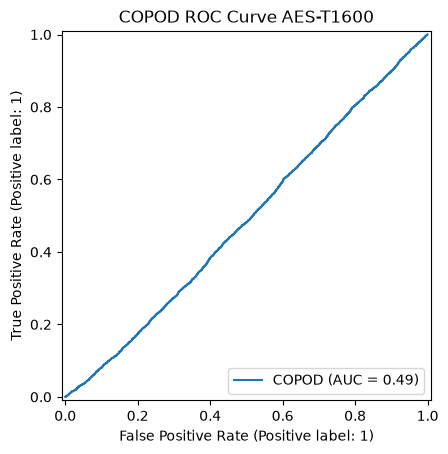

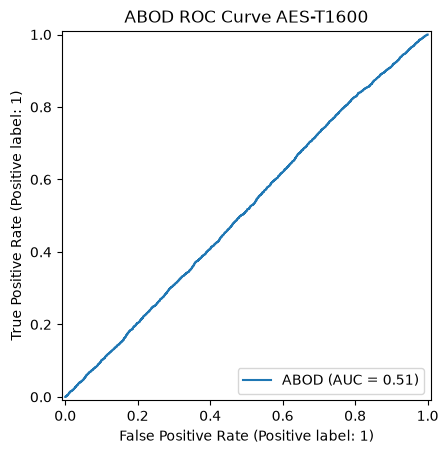

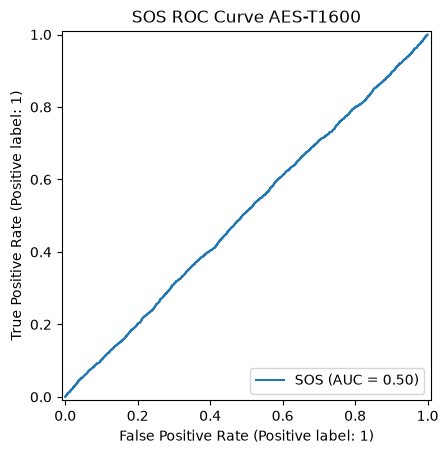

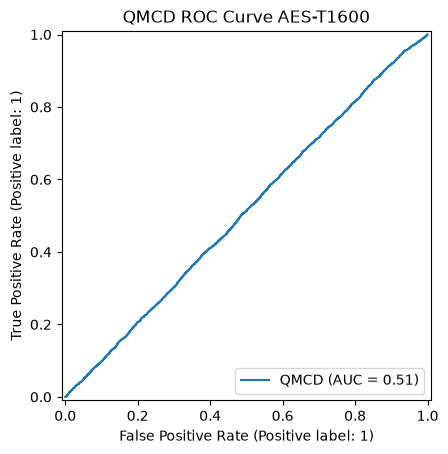

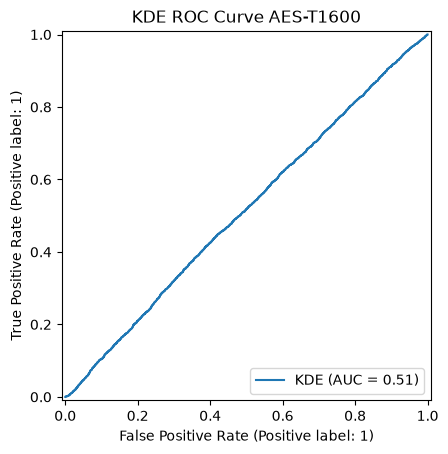

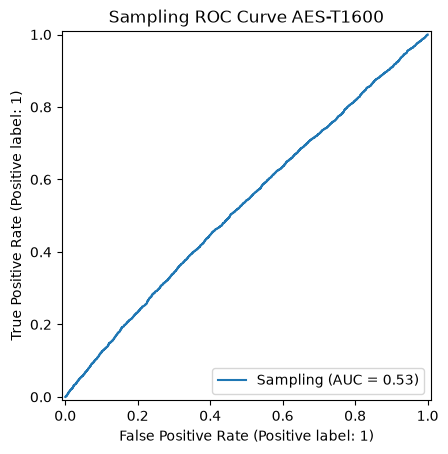

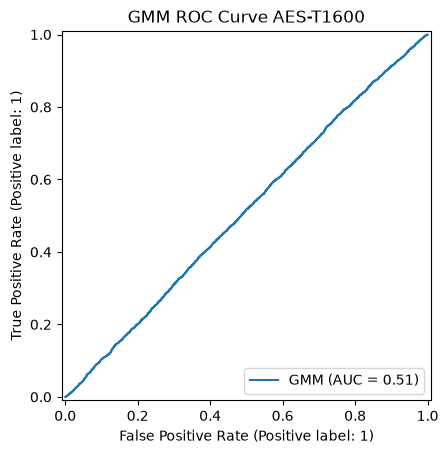

,model,roc_auc,pr_auc,inverted
6,Sampling,0.528396,0.687833,False
5,KDE,0.513442,0.670577,False
2,ABOD,0.512661,0.670774,False
7,GMM,0.510805,0.668868,False
4,QMCD,0.510220,0.670142,False
3,SOS,0.503450,0.671669,False
1,COPOD,0.488217,0.651671,True
0,ECOD,0.465481,0.637811,True


In [ ]:
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.mad import MAD
from pyod.models.sos import SOS
from pyod.models.qmcd import QMCD
from pyod.models.kde import KDE
from pyod.models.sampling import Sampling
from pyod.models.gmm import GMM

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Probabilistic
    "ECOD": (lambda: ECOD(), True),
    "COPOD": (lambda: COPOD(), True),
    "ABOD": (lambda: ABOD(), False),
    # MAD omitted, see below
    "SOS": (lambda: SOS(), False),
    "QMCD": (lambda: QMCD(), False),
    "KDE": (lambda: KDE(), False),
    "Sampling": (lambda: Sampling(), False),
    "GMM": (lambda: GMM(), False),
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}01_probabilistic_results.csv", index=True)
display(results_df)

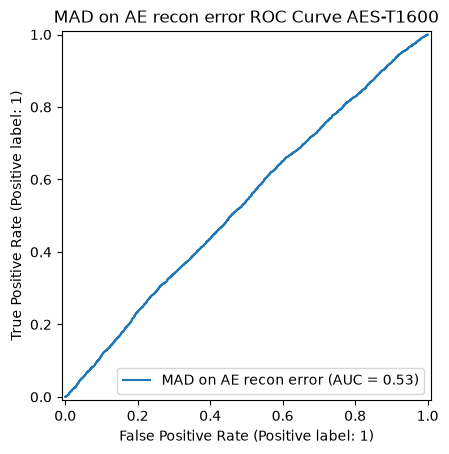

,model,roc_auc,pr_auc
0,MAD on AE recon error,0.530685,0.683308


In [ ]:
# MAD

from pyod.models.mad import MAD

mad = MAD()
mad.fit(err_train.reshape(-1, 1))

s_norm = mad.decision_function(err_test_norm.reshape(-1, 1))
s_anom = mad.decision_function(err_test_anom.reshape(-1, 1))

results_df = pd.DataFrame([compute_metrics("MAD on AE recon error", s_norm, s_anom)])
results_df.to_csv(f"{DFS}02_MAD_results.csv", index=True)
display(results_df)

### Linear Models

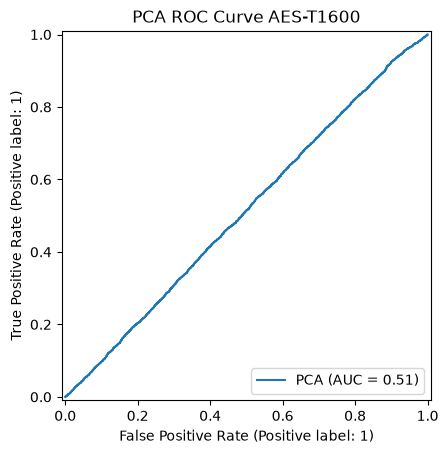

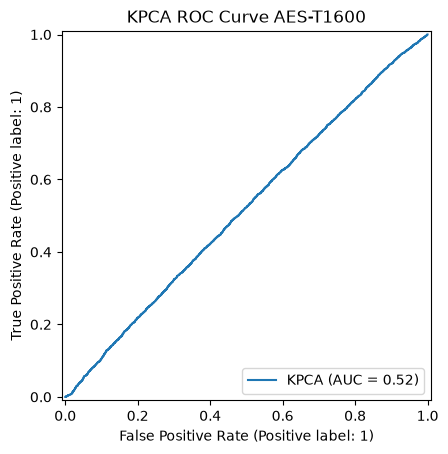

Streaming output truncated to the last 5000 lines.
/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-pac

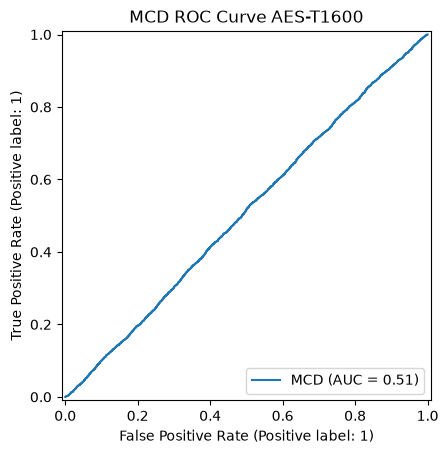

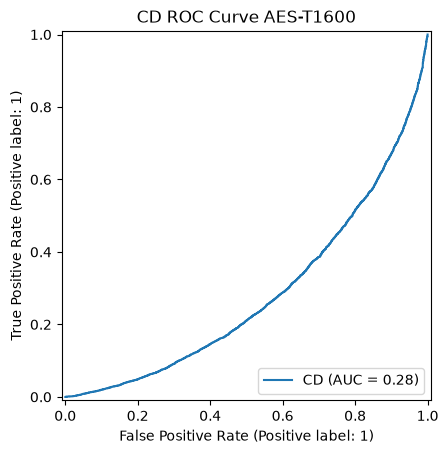

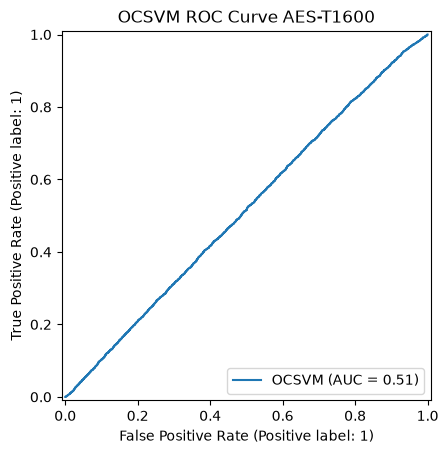

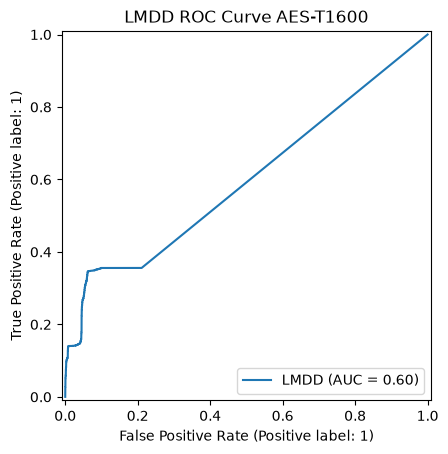

,model,roc_auc,pr_auc,inverted
5,LMDD,0.598778,0.762990,False
1,KPCA,0.518348,0.674000,False
4,OCSVM,0.514283,0.671304,False
0,PCA,0.511762,0.669698,False
2,MCD,0.507626,0.665683,False
3,CD,0.282208,0.534942,False


In [ ]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.mcd import MCD
from pyod.models.cd import CD
from pyod.models.ocsvm import OCSVM
from pyod.models.lmdd import LMDD

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    "PCA": (lambda: PCA(), False),
    "KPCA": (lambda: KPCA(), False),
    "MCD": (lambda: MCD(), False),
    "CD": (lambda: CD(), False),
    "OCSVM": (lambda: OCSVM(), False),
    "LMDD": (lambda: LMDD(), False)
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}03_linear_results.csv", index=True)
display(results_df)

### Proximity-Based

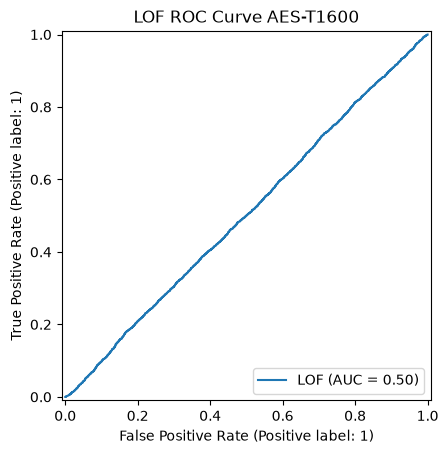

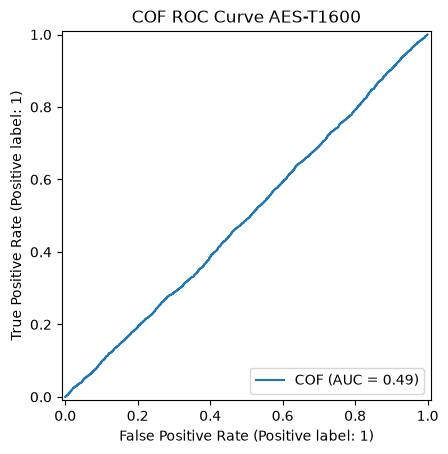

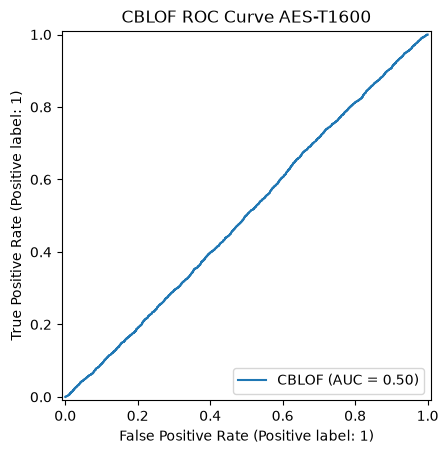

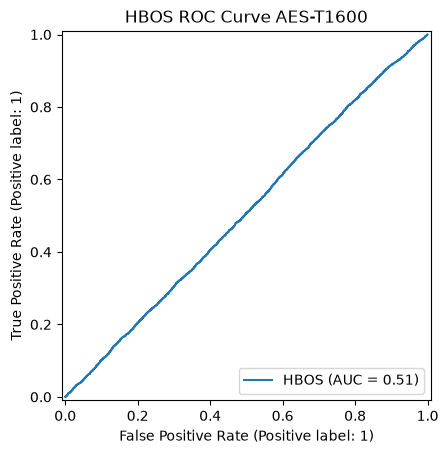

/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


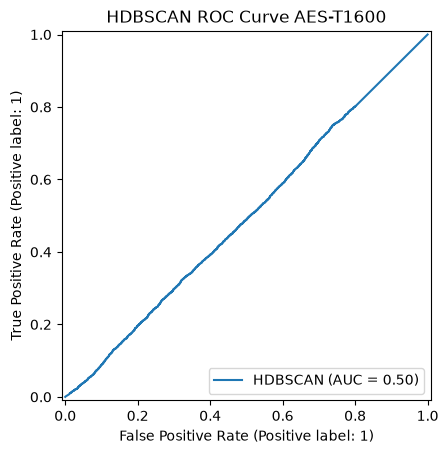

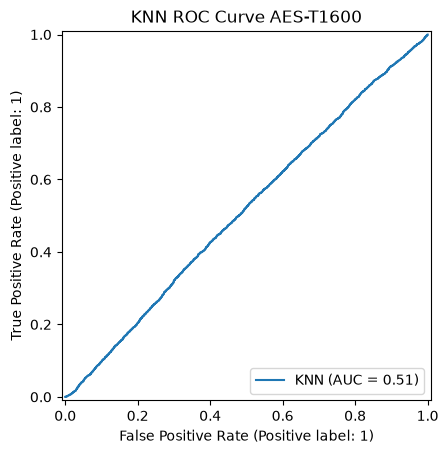

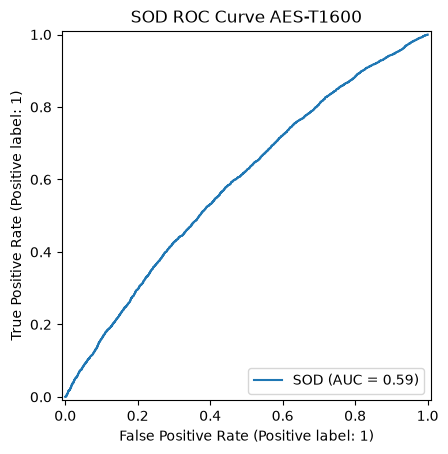

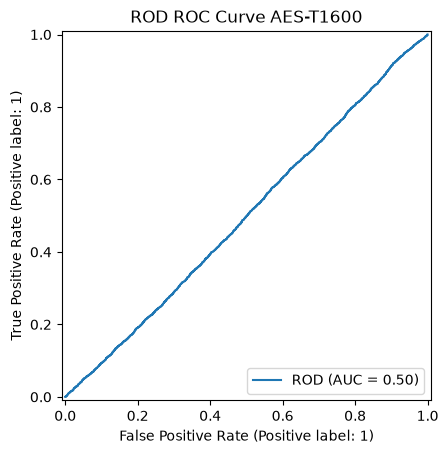

,model,roc_auc,pr_auc,inverted
6,SOD,0.590644,0.726697,True
5,KNN,0.513472,0.668163,False
3,HBOS,0.508644,0.669633,False
0,LOF,0.503733,0.664592,False
2,CBLOF,0.501529,0.661961,False
7,ROD,0.498377,0.662425,False
4,HDBSCAN,0.495813,0.659118,False
1,COF,0.493957,0.662160,False


In [ ]:
# IMPORT MODELS HERE
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.cblof import CBLOF
from pyod.models.loci import LOCI
from pyod.models.hbos import HBOS
from pyod.models.hdbscan import HDBSCAN
from pyod.models.knn import KNN
from pyod.models.sod import SOD
from pyod.models.rod import ROD

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Proximity-Based
    "LOF": (lambda: LOF(), False),
    "COF": (lambda: COF(), False),
    "CBLOF": (lambda: CBLOF(n_clusters=20, random_state=SEED), False),
    #"LOCI": (lambda: LOCI(), False), OMITTED - Timeout on every run
    "HBOS": (lambda: HBOS(), False),
    "HDBSCAN": (lambda: HDBSCAN(), False),
    "KNN": (lambda: KNN(), False),
    "SOD": (lambda: SOD(), True),
    "ROD": (lambda: ROD(), False)
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}04_proximity_based_results.csv", index=True)
display(results_df)

### Outlier Ensembles

In [ ]:
# LSCP
from pyod.models.lscp import LSCP

# Make the LSCP classifier, consists of:
# KNN, LOF, iForest, and OCSVM models
def make_lscp():
  base = [
      KNN(n_neighbors=10),
      LOF(n_neighbors=10),
      IForest(random_state=SEED),
      OCSVM(),
  ]
  return LSCP(
      detector_list=base,
      local_region_size=30,
      n_bins=len(base),
      random_state=SEED,
  )

# SUOD
from pyod.models.suod import SUOD

%pip install suod

# Make the SUOD classifier, consists of:
# KNN (10 neighbors), KNN (20 neighbors), KNN (20 neighbors), LOF (10 neighbors), iForest, OCSVM
def make_suod():
  base = [
      KNN(n_neighbors=10),
      KNN(n_neighbors=20),
      KNN(n_neighbors=20),
      LOF(n_neighbors=10),
      IForest(random_state=SEED),
      OCSVM()
  ]
  return SUOD(
      base_estimators=base,
      combination="average",
      rp_flag_global=False,
      approx_flag_global=False,
      bps_flag=True,
      n_jobs=2,
      verbose=False,
  )

Note: you may need to restart the kernel to use updated packages.


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    1.6s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_9629_98a286e946454f6da89fb133a070bf91_c8518e6a9d9c4933b5cc24da2fbdec47/9629-5181198272-20f3b797740d48d69fafbe2015dc7176.pkl'
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.6s finished
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_9629_98a286e946454f6da89fb133a070bf91_c8518e6a9d9c4933b5cc24da2fbdec47/9629-518119

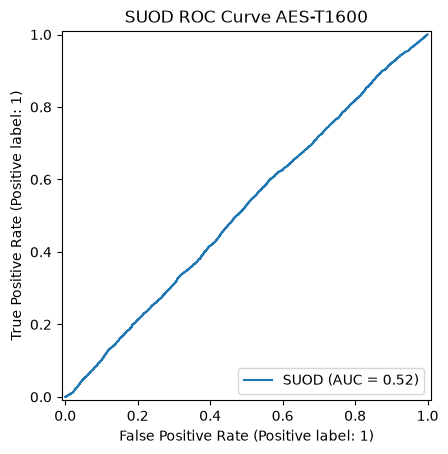

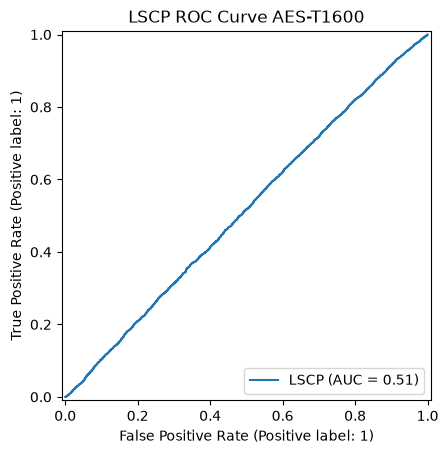

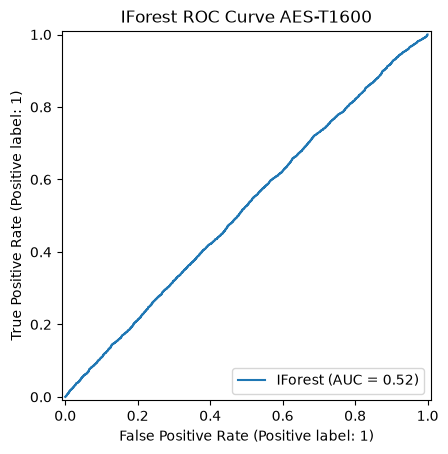

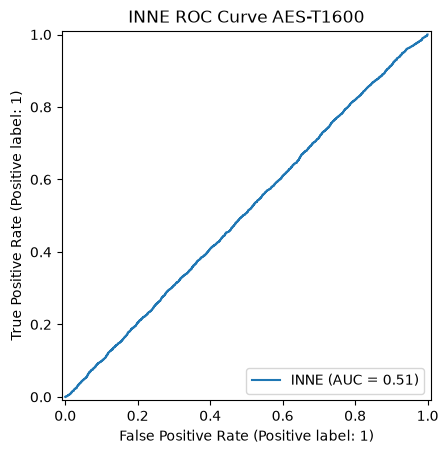

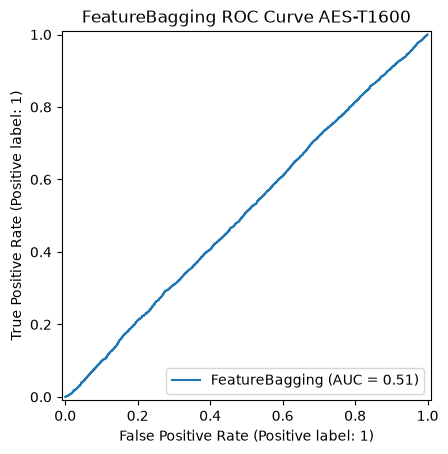

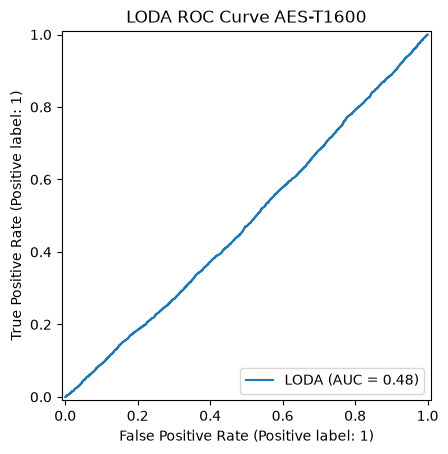

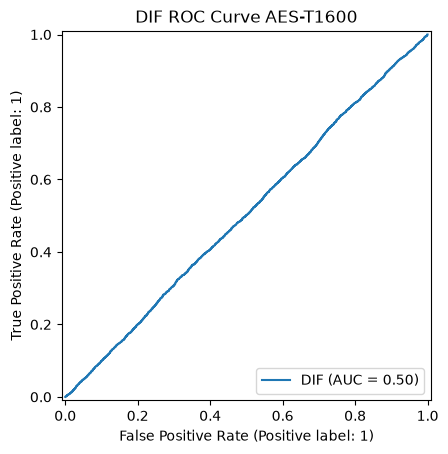

,model,roc_auc,pr_auc,inverted
2,IForest,0.519201,0.679086,False
0,SUOD,0.515638,0.671158,False
1,LSCP,0.513101,0.670403,False
3,INNE,0.508882,0.667516,False
4,FeatureBagging,0.507984,0.666311,False
6,DIF,0.504638,0.666847,False
5,LODA,0.482418,0.653563,False


In [ ]:
# IMPORT MODELS HERE
from pyod.models.iforest import IForest
from pyod.models.inne import INNE
from pyod.models.dif import DIF
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.loda import LODA
from pyod.models.ocsvm import OCSVM

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Outlier Ensembles
    "SUOD": (lambda: make_suod(), False),
    "LSCP": (lambda: make_lscp(), False),
    "IForest": (lambda: IForest(random_state=SEED), False),
    "INNE": (lambda: INNE(random_state=SEED), False),
    "FeatureBagging": (lambda: FeatureBagging(random_state=SEED), False),
    "LODA": (lambda: LODA(), False),
    "DIF": (lambda: DIF(random_state=SEED), False),
    # XGBOD Omitted - Not compatible with semi-supervised application
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}05_outlier_ensembles_results.csv", index=True)
display(results_df)

### Neural Networks

In [16]:
# Defines the random seed for reproducable results.
def seeded(builder):
  def make():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    return builder()
  return make

Note: you may need to restart the kernel to use updated packages.
Epoch 1/100, Loss: 64.47566393017769
Epoch 2/100, Loss: 51.239292293787
Epoch 3/100, Loss: 43.914185270667076
Epoch 4/100, Loss: 37.48918017745018
Epoch 5/100, Loss: 31.460300594568253
Epoch 6/100, Loss: 25.948033064603806
Epoch 7/100, Loss: 21.01835074275732
Epoch 8/100, Loss: 16.918550193309784
Epoch 9/100, Loss: 13.678364925086498
Epoch 10/100, Loss: 11.215502433478832
Epoch 11/100, Loss: 9.368867117911577
Epoch 12/100, Loss: 7.93917054310441
Epoch 13/100, Loss: 6.842282071709633
Epoch 14/100, Loss: 5.979512566700578
Epoch 15/100, Loss: 5.276562325656414
Epoch 16/100, Loss: 4.705974493175745
Epoch 17/100, Loss: 4.240706145763397
Epoch 18/100, Loss: 3.8403603192418814
Epoch 19/100, Loss: 3.503791281953454
Epoch 20/100, Loss: 3.2211330998688936
Epoch 21/100, Loss: 2.9785988153889775
Epoch 22/100, Loss: 2.7709397645667195
Epoch 23/100, Loss: 2.5601059682667255
Epoch 24/100, Loss: 2.3902210975065827
Epoch 25/100, Loss: 2.

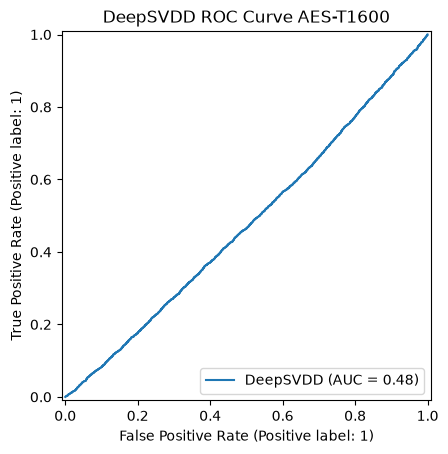

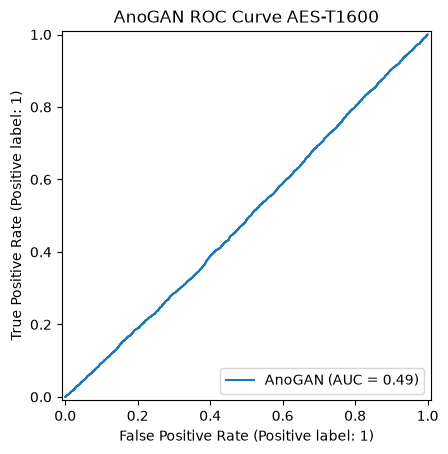

Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 11.57it/s]


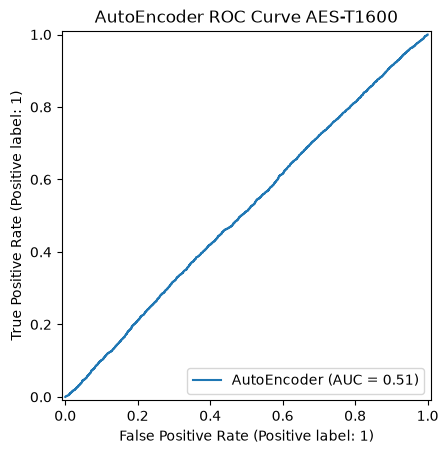

Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 17.36it/s]


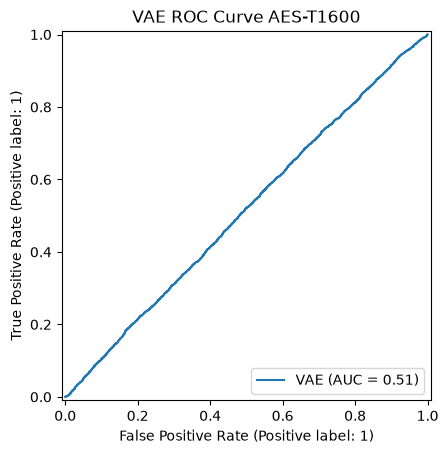

Epoch 10/50, Loss: 2.4489882151792
Epoch 20/50, Loss: 1.3335708356966638
Epoch 30/50, Loss: 0.9594237166605178
Epoch 40/50, Loss: 0.9025893310073075
Epoch 50/50, Loss: 0.8844259681215711


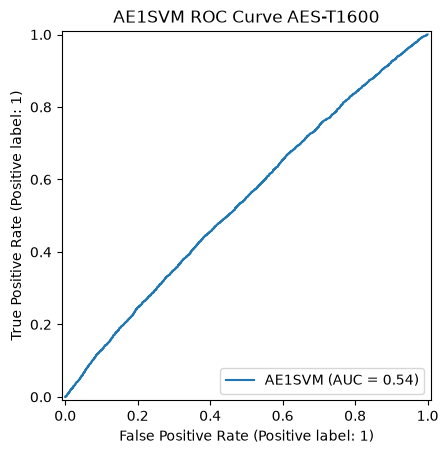

Epoch 1 of 60
Epoch 2 of 60
Epoch 3 of 60
Epoch 4 of 60
Epoch 5 of 60
Epoch 6 of 60
Epoch 7 of 60
Epoch 8 of 60
Epoch 9 of 60
Epoch 10 of 60
Epoch 11 of 60
Epoch 12 of 60
Epoch 13 of 60
Epoch 14 of 60
Epoch 15 of 60
Epoch 16 of 60
Epoch 17 of 60
Epoch 18 of 60
Epoch 19 of 60
Epoch 20 of 60
Epoch 21 of 60
Epoch 22 of 60
Epoch 23 of 60
Epoch 24 of 60
Epoch 25 of 60
Epoch 26 of 60
Epoch 27 of 60
Epoch 28 of 60
Epoch 29 of 60
Epoch 30 of 60
Epoch 31 of 60
Epoch 32 of 60
Epoch 33 of 60
Epoch 34 of 60
Epoch 35 of 60
Epoch 36 of 60
Epoch 37 of 60
Epoch 38 of 60
Epoch 39 of 60
Epoch 40 of 60
Epoch 41 of 60
Epoch 42 of 60
Epoch 43 of 60
Epoch 44 of 60
Epoch 45 of 60
Epoch 46 of 60
Epoch 47 of 60
Epoch 48 of 60
Epoch 49 of 60
Epoch 50 of 60
Epoch 51 of 60
Epoch 52 of 60
Epoch 53 of 60
Epoch 54 of 60
Epoch 55 of 60
Epoch 56 of 60
Epoch 57 of 60
Epoch 58 of 60
Epoch 59 of 60
Epoch 60 of 60


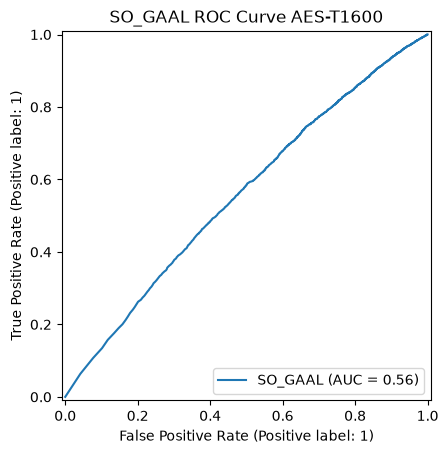

Epoch 1 of 60
Epoch 2 of 60
Epoch 3 of 60
Epoch 4 of 60
Epoch 5 of 60
Epoch 6 of 60
Epoch 7 of 60
Epoch 8 of 60
Epoch 9 of 60
Epoch 10 of 60
Epoch 11 of 60
Epoch 12 of 60
Epoch 13 of 60
Epoch 14 of 60
Epoch 15 of 60
Epoch 16 of 60
Epoch 17 of 60
Epoch 18 of 60
Epoch 19 of 60
Epoch 20 of 60
Epoch 21 of 60
Epoch 22 of 60
Epoch 23 of 60
Epoch 24 of 60
Epoch 25 of 60
Epoch 26 of 60
Epoch 27 of 60
Epoch 28 of 60
Epoch 29 of 60
Epoch 30 of 60
Epoch 31 of 60
Epoch 32 of 60
Epoch 33 of 60
Epoch 34 of 60
Epoch 35 of 60
Epoch 36 of 60
Epoch 37 of 60
Epoch 38 of 60
Epoch 39 of 60
Epoch 40 of 60
Epoch 41 of 60
Epoch 42 of 60
Epoch 43 of 60
Epoch 44 of 60
Epoch 45 of 60
Epoch 46 of 60
Epoch 47 of 60
Epoch 48 of 60
Epoch 49 of 60
Epoch 50 of 60
Epoch 51 of 60
Epoch 52 of 60
Epoch 53 of 60
Epoch 54 of 60
Epoch 55 of 60
Epoch 56 of 60
Epoch 57 of 60
Epoch 58 of 60
Epoch 59 of 60
Epoch 60 of 60


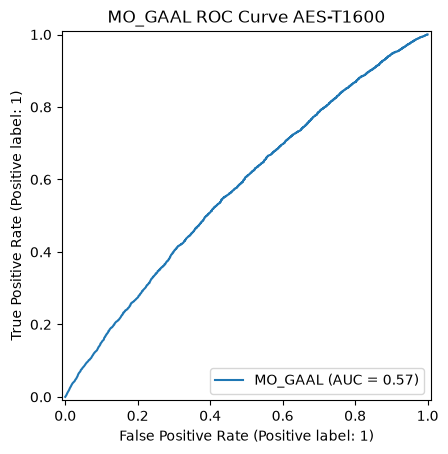

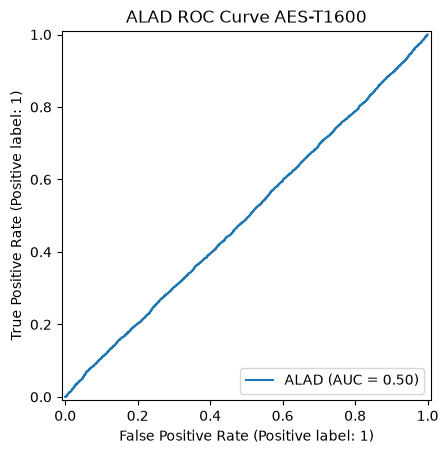

,model,roc_auc,pr_auc,inverted
6,MO_GAAL,0.574926,0.719048,False
5,SO_GAAL,0.557985,0.705870,False
4,AE1SVM,0.539541,0.694075,False
3,VAE,0.513219,0.671680,False
2,AutoEncoder,0.512151,0.669853,False
7,ALAD,0.497431,0.668295,False
1,AnoGAN,0.492108,0.659049,False
0,DeepSVDD,0.475601,0.649006,False


In [18]:
%pip install tqdm

from pyod.models.deep_svdd import DeepSVDD
from pyod.models.anogan import AnoGAN
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.vae import VAE
from pyod.models.ae1svm import AE1SVM
from pyod.models.so_gaal import SO_GAAL
from pyod.models.mo_gaal import MO_GAAL
from pyod.models.alad import ALAD
from pyod.models.lunar import LUNAR

N_LATENT = Z_train_s.shape[1]

neural = {
    # Neural Network Models
    "DeepSVDD": (seeded(lambda: DeepSVDD(n_features=N_LATENT, random_state=SEED)), False),
    "AnoGAN": (seeded(lambda: AnoGAN()), False),
    "AutoEncoder": (seeded(lambda: AutoEncoder(hidden_neuron_list=[16,8], random_state=SEED)), False),
    "VAE": (seeded(lambda: VAE(encoder_neuron_list=[16, 8], decoder_neuron_list=[8, 16], latent_dim=4, random_state=SEED)), False),
    "AE1SVM": (seeded(lambda: AE1SVM()), False),
    "SO_GAAL": (seeded(lambda: SO_GAAL()), False),
    "MO_GAAL": (seeded(lambda: MO_GAAL()), False),
    "ALAD": (seeded(lambda: ALAD()), False),
}

neural_results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in neural.items()
]

results_df = pd.DataFrame(neural_results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}06_neural_network_results.csv", index=True)
display(results_df)

### Time-Series OD

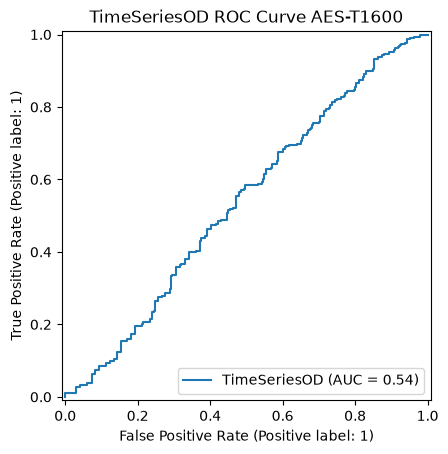

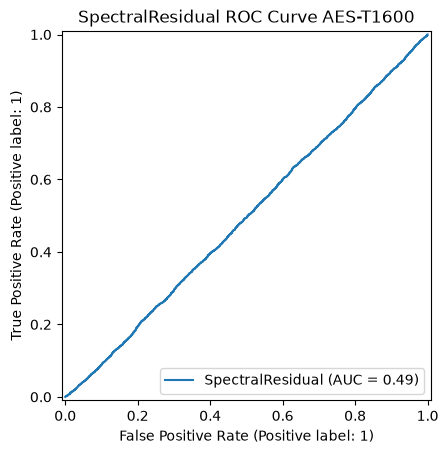

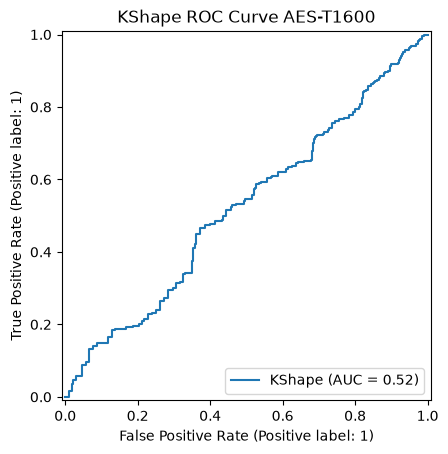

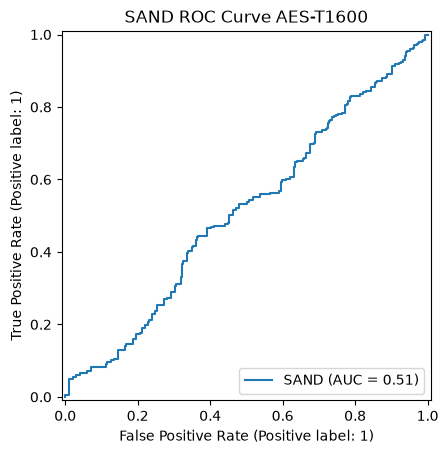

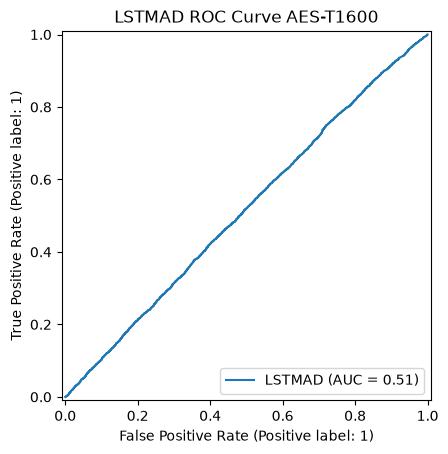

,model,roc_auc,pr_auc,inverted
0,TimeSeriesOD,0.537066,0.677935,False
2,KShape,0.522110,0.690103,False
4,LSTMAD,0.514667,0.673342,False
3,SAND,0.510888,0.679749,False
1,SpectralResidual,0.494996,0.659365,False


In [ ]:
from pyod.models.ts_od import TimeSeriesOD
from pyod.models.ts_spectral_residual import SpectralResidual
from pyod.models.ts_kshape import KShape
from pyod.models.ts_sand import SAND
from pyod.models.ts_lstm import LSTMAD
from pyod.models.ts_anomaly_transformer import AnomalyTransformer

detectors = {
    # Time Series OD models
    "TimeSeriesOD": (lambda: TimeSeriesOD(), False),
    "SpectralResidual": (lambda: SpectralResidual(), False),
    "KShape": (lambda: KShape(), False),
    "SAND": (lambda: SAND(), False),
    "LSTMAD": (lambda: LSTMAD(), False),
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}07_time_series_od_results.csv", index=True)
display(results_df)

### Graph-Based Models

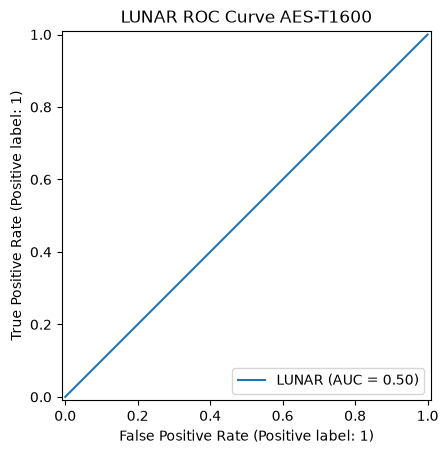

,model,roc_auc,pr_auc,inverted
0,LUNAR,0.5,0.5,False


In [15]:
from pyod.models.lunar import LUNAR
from pyod.models.rgraph import RGraph
from pyod.models.embedding import EmbeddingOD

detectors = {
    # Graph and embedding based
    "LUNAR": (lambda: LUNAR(), False),
    #"RGraph": (lambda: RGraph(blocksize_test_data=200), False),
}

results = [
    evaluate_detector(name, make, Z_train_s, Z_test_norm_s, Z_test_norm_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{DFS}08_graph_based_results.csv", index=True)
display(results_df)

### PyOD PCA on raw data

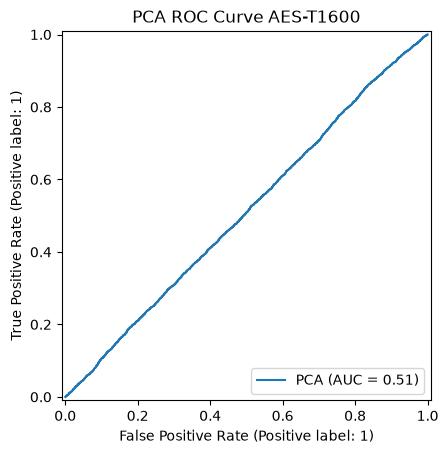

,model,roc_auc,pr_auc,inverted
0,PCA,0.510207,0.670606,False


In [22]:
from pyod.models.pca import PCA

detectors = {
    "PCA": (lambda: PCA(), False),
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)